This notebook is to carry out analysis on lung cancer and it's correlation based on the features shared by the dataset. 
The first step would be to visualise the data

In [1]:
import research as research
import matplotlib.pyplot as plt

data = research.load_and_preprocess_data('lung_cancer_survey.csv')

stats_results = research.descriptive_statistics(data)

  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                    2                      

Descriptive statistics

 Generating visualisations

 Histograms for Continuous Variables


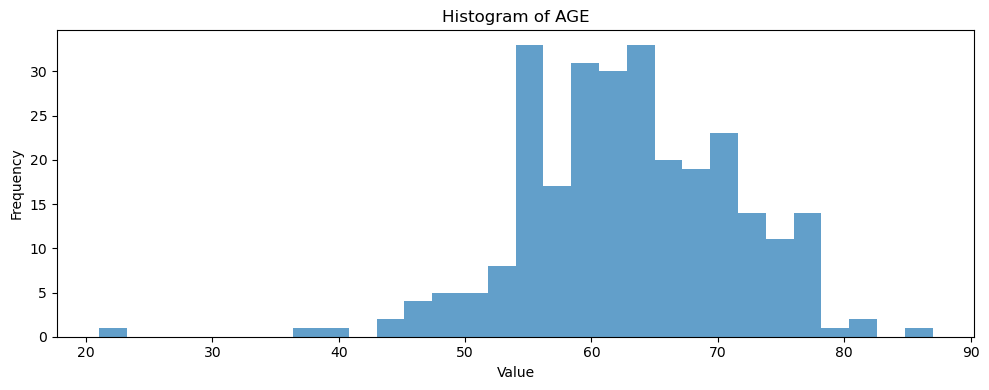


 Boxplots for Continuous Variables


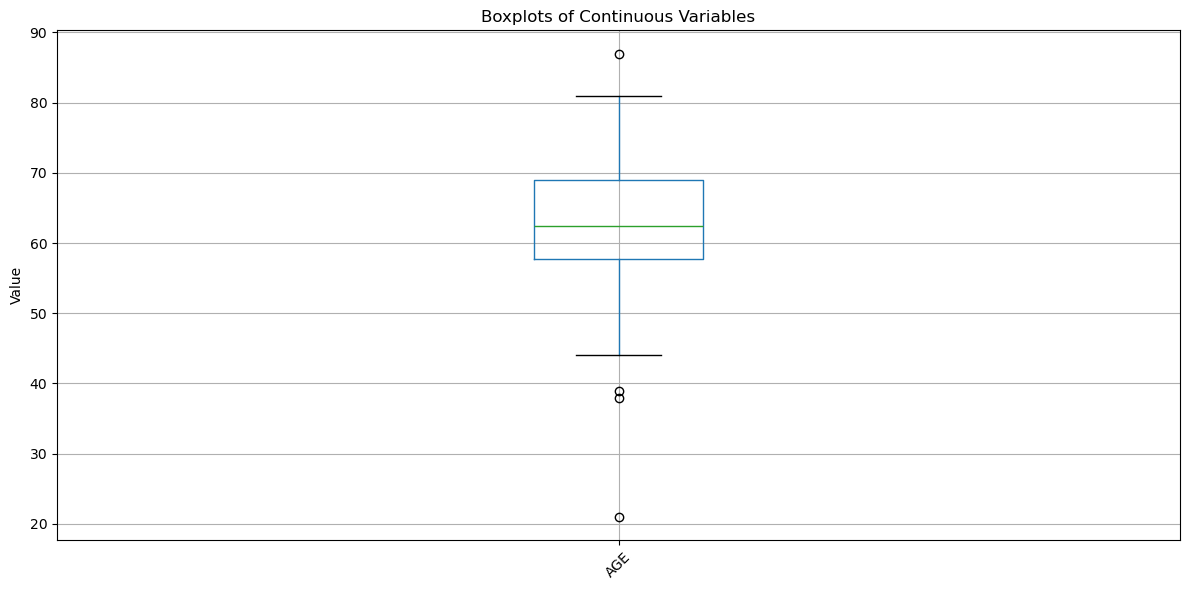


 Bar Charts for Categorical Variables


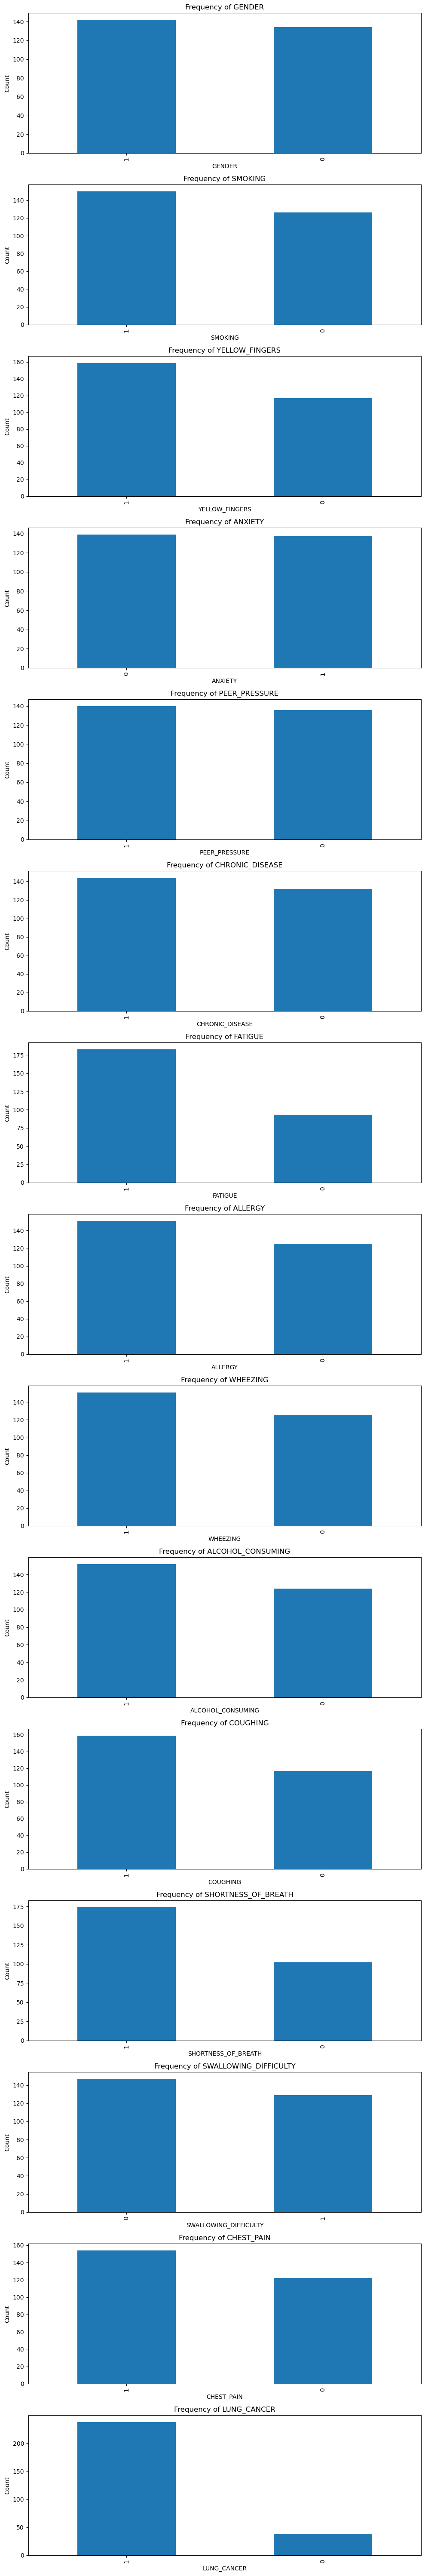


 visualisation of Lung Cancer Correlations


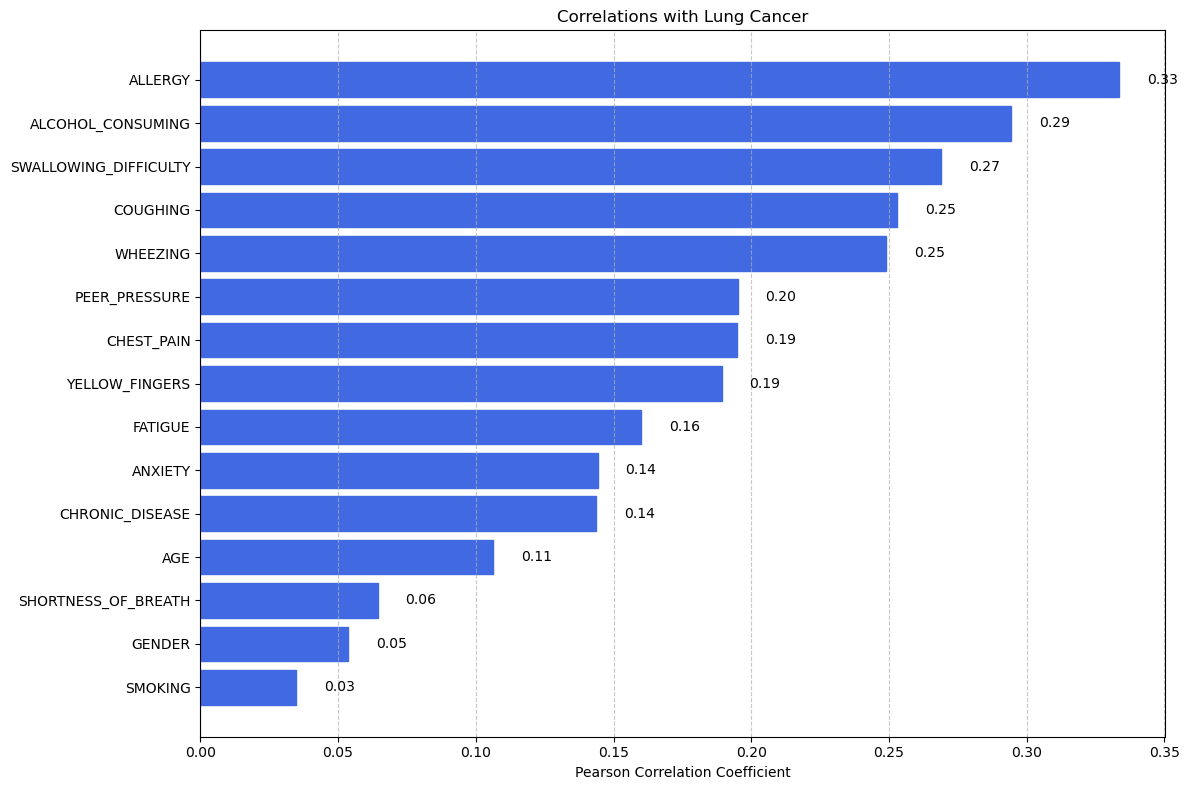


 Key Factor Correlation Heatmap


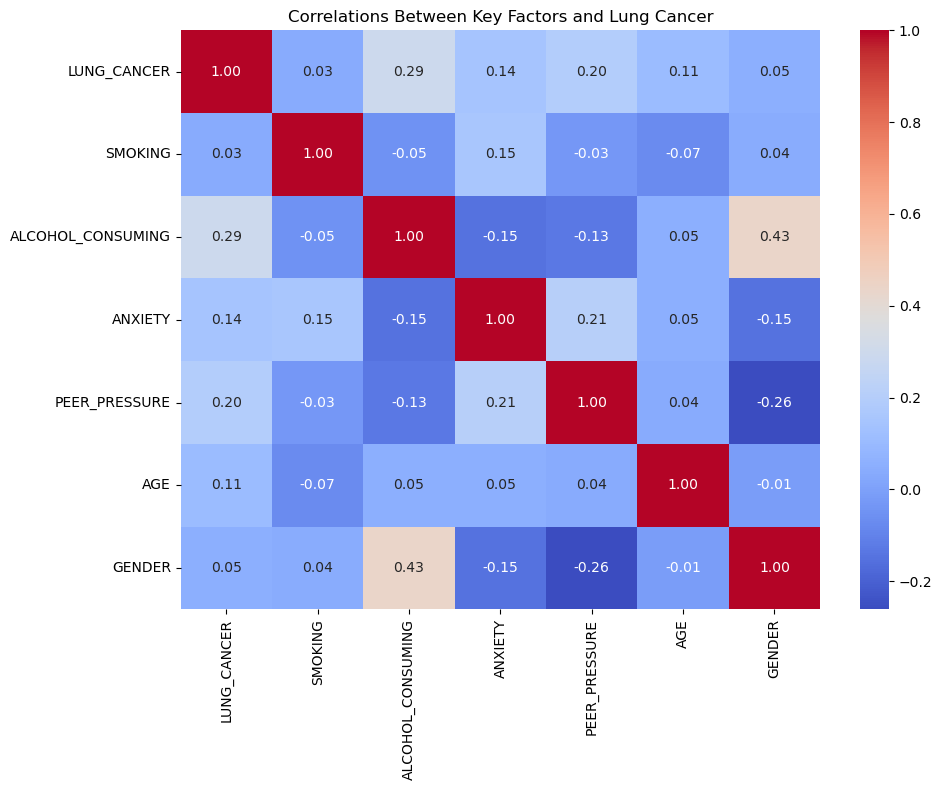


 Detailed Results for Report

 Continuous Variable Statistics

 AGE
- Mean: 62.91
- Median: 62.50
- Mode: 64
- Standard Deviation: 8.38
- Variance: 70.21
- Minimum: 21
- Maximum: 87
- Quartiles: Q1=57.75, Q2=62.50, Q3=69.00
- Interquartile Range (IQR): 11.25

 Categorical Variable Statistics

 GENDER
- Unique Values: 2
- Mode: 1 (Count: 142, 51.45%)
- Frequency Table:
| Value | Frequency | Percentage |
|-------|-----------|------------|
| 1 | 142 | 51.45% |
| 0 | 134 | 48.55% |

 SMOKING
- Unique Values: 2
- Mode: 1 (Count: 150, 54.35%)
- Frequency Table:
| Value | Frequency | Percentage |
|-------|-----------|------------|
| 1 | 150 | 54.35% |
| 0 | 126 | 45.65% |

 YELLOW_FINGERS
- Unique Values: 2
- Mode: 1 (Count: 159, 57.61%)
- Frequency Table:
| Value | Frequency | Percentage |
|-------|-----------|------------|
| 1 | 159 | 57.61% |
| 0 | 117 | 42.39% |

 ANXIETY
- Unique Values: 2
- Mode: 0 (Count: 139, 50.36%)
- Frequency Table:
| Value | Frequency | Percentage |
|-------|----

In [2]:
print(" Generating visualisations")

print("\n Histograms for Continuous Variables")
hist_fig = stats_results['visualisations']['histograms']()
plt.show()

print("\n Boxplots for Continuous Variables")
box_fig = stats_results['visualisations']['boxplots']()
plt.show()

print("\n Bar Charts for Categorical Variables")
bar_fig = stats_results['visualisations']['bar_charts']()
plt.show()

# print("\n Correlation Heatmap")
# corr_fig = stats_results['visualisations']['correlation_heatmap']()
# plt.show()

print("\n visualisation of Lung Cancer Correlations")
lung_corr_fig = stats_results['visualisations']['lung_cancer_correlations']()
plt.show()

print("\n Key Factor Correlation Heatmap")
factor_corr_fig = stats_results['visualisations']['factor_correlations']()
plt.show()

print("\n Detailed Results for Report")

print("\n Continuous Variable Statistics")
for var, stats in stats_results['continuous'].items():
    print(f"\n {var}")
    print(f"- Mean: {stats['mean']:.2f}")
    print(f"- Median: {stats['median']:.2f}")
    print(f"- Mode: {stats['mode']}")
    print(f"- Standard Deviation: {stats['std_dev']:.2f}")
    print(f"- Variance: {stats['variance']:.2f}")
    print(f"- Minimum: {stats['min']}")
    print(f"- Maximum: {stats['max']}")
    print(f"- Quartiles: Q1={stats['quartiles'][0]:.2f}, Q2={stats['quartiles'][1]:.2f}, Q3={stats['quartiles'][2]:.2f}")
    print(f"- Interquartile Range (IQR): {stats['IQR']:.2f}")

print("\n Categorical Variable Statistics")
for var, stats in stats_results['categorical'].items():
    print(f"\n {var}")
    print(f"- Unique Values: {stats['unique_values']}")
    print(f"- Mode: {stats['mode']['value']} (Count: {stats['mode']['count']}, {stats['mode']['percentage']:.2f}%)")
    
    print(f"- Frequency Table:")
    freq_table = stats['frequency_table']
    print("| Value | Frequency | Percentage |")
    print("|-------|-----------|------------|")
    for idx, row in freq_table.iterrows():
        print(f"| {idx} | {int(row['frequency'])} | {row['percentage']:.2f}% |")

print("\n Correlation Analysis")
print("\n Top Correlations")
print("| Variable 1 | Variable 2 | Correlation |")
print("|------------|------------|------------|")
for var1, var2, corr in stats_results['correlation']['top_correlations']:
    print(f"| {var1} | {var2} | {corr:.4f} |")

print("\n Strongest Correlations")
abs_corr_pairs = [(v1, v2, corr) for v1, v2, corr in stats_results['correlation']['top_correlations']]
abs_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("\nStrongest Positive Correlations:")
print("| Variable 1 | Variable 2 | Correlation |")
print("|------------|------------|------------|")
for var1, var2, corr in [p for p in abs_corr_pairs if p[2] > 0][:5]:
    print(f"| {var1} | {var2} | {corr:.4f} |")

print("\nStrongest Negative Correlations:")
print("| Variable 1 | Variable 2 | Correlation |")
print("|------------|------------|------------|")
for var1, var2, corr in [p for p in abs_corr_pairs if p[2] < 0][:5]:
    print(f"| {var1} | {var2} | {corr:.4f} |")
    
print("\n Correlations with Lung Cancer")
print("| Variable | Correlation with Lung Cancer |")
print("|----------|------------------------------|")
for var, corr in stats_results['correlation']['top_lung_cancer_correlations']:
    print(f"| {var} | {corr:.4f} |")

print("\n Psychosocial Factors and Lung Cancer")
print("| Factor | Correlation with Lung Cancer |")
print("|--------|------------------------------|")
for factor, corr in stats_results['correlation']['psychosocial_correlations'].items():
    print(f"| {factor} | {corr:.4f} |")

print("\n Behavioral Habits and Lung Cancer")
print("| Habit | Correlation with Lung Cancer |")
print("|-------|------------------------------|")
for habit, corr in stats_results['correlation']['behavioral_correlations'].items():
    print(f"| {habit} | {corr:.4f} |")

Cancer Features Distribuition Visualisations


 Cancer Distribution Visualisations

Cancer Distribution:
Lung Cancer (Yes): 86.23%
No Lung Cancer (No): 13.77%

Cancer Distribution by Features:

SMOKING:
  No: 84.92% have lung cancer
  Yes: 87.33% have lung cancer

YELLOW_FINGERS:
  No: 78.63% have lung cancer
  Yes: 91.82% have lung cancer

ANXIETY:
  No: 81.29% have lung cancer
  Yes: 91.24% have lung cancer

PEER_PRESSURE:
  No: 79.41% have lung cancer
  Yes: 92.86% have lung cancer

CHRONIC_DISEASE:
  No: 81.06% have lung cancer
  Yes: 90.97% have lung cancer

FATIGUE:
  No: 78.49% have lung cancer
  Yes: 90.16% have lung cancer

ALLERGY:
  No: 73.60% have lung cancer
  Yes: 96.69% have lung cancer

WHEEZING:
  No: 76.80% have lung cancer
  Yes: 94.04% have lung cancer

ALCOHOL_CONSUMING:
  No: 75.00% have lung cancer
  Yes: 95.39% have lung cancer

COUGHING:
  No: 76.07% have lung cancer
  Yes: 93.71% have lung cancer

SHORTNESS_OF_BREATH:
  No: 83.33% have lung cancer
  Yes: 87.93% have lung cancer

SWALLOWING_DIFFICULTY:
  N

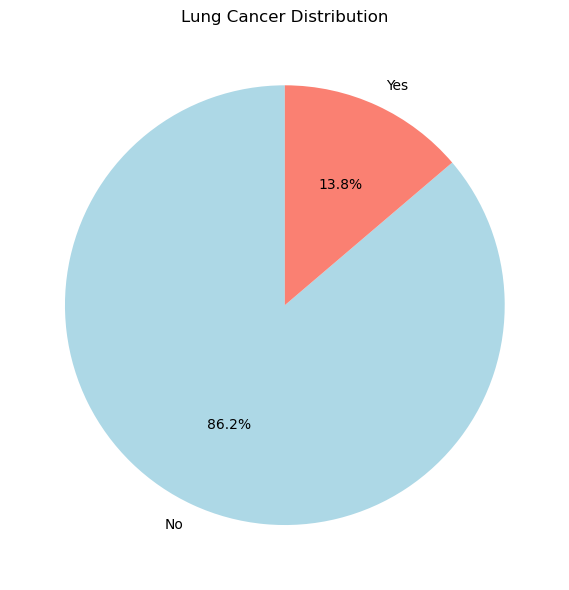


 Cancer Distribution by Individual Factors


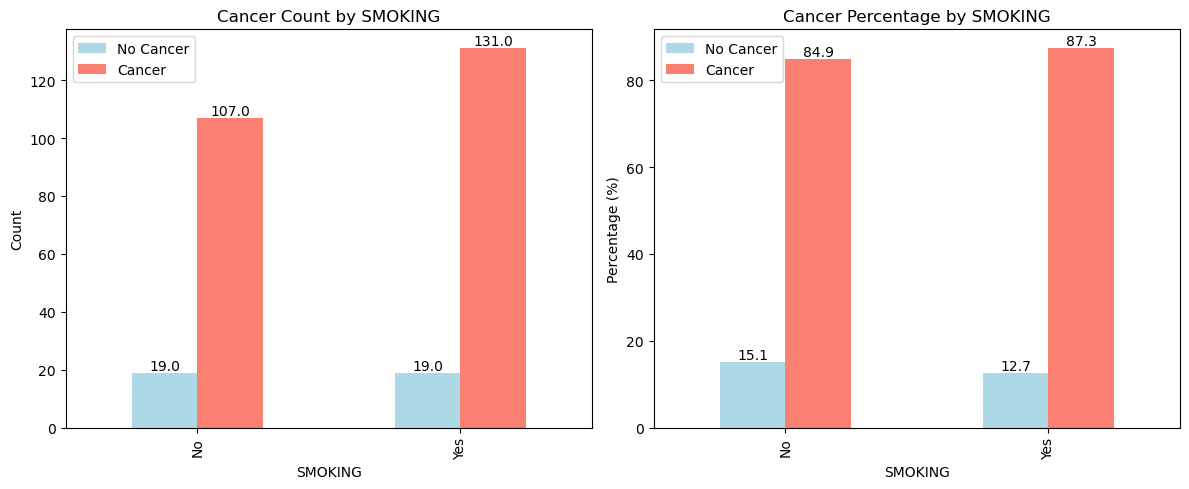

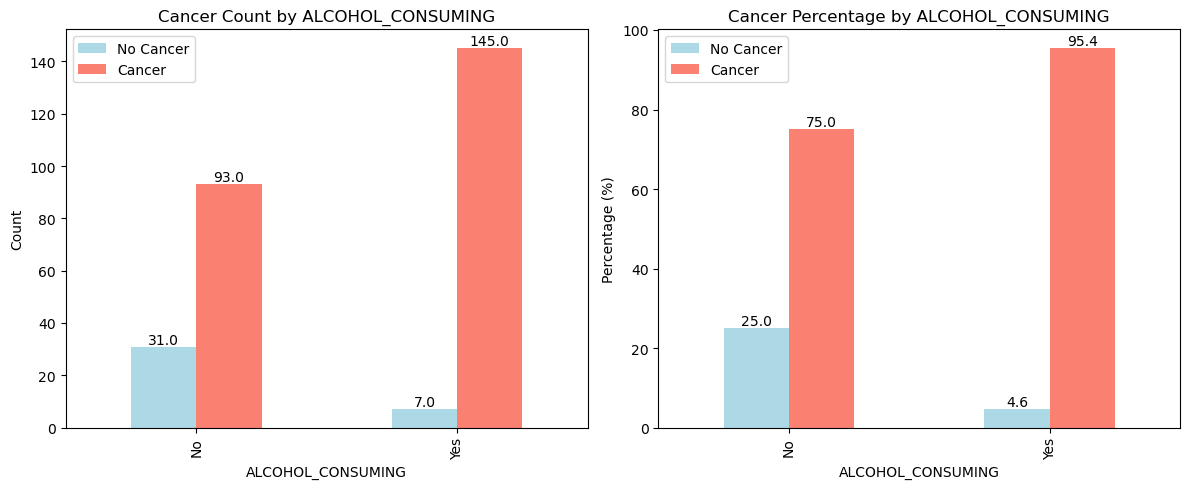

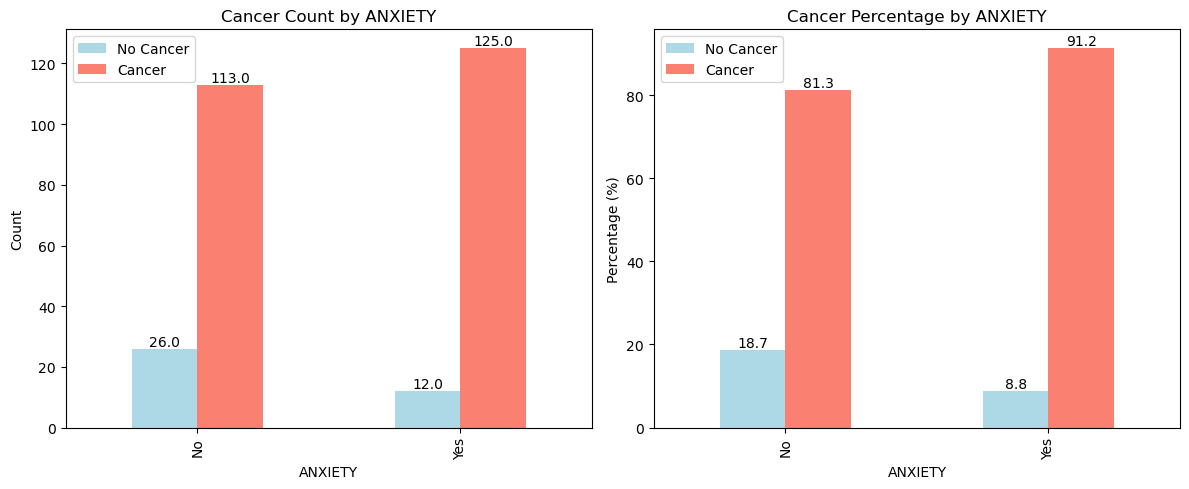

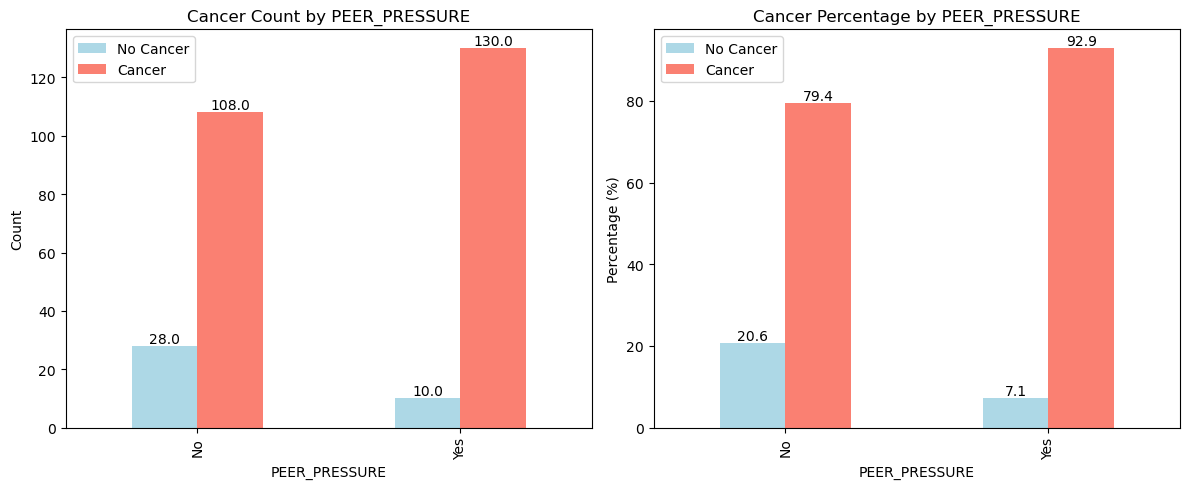


 Cancer Distribution by Combined Factors


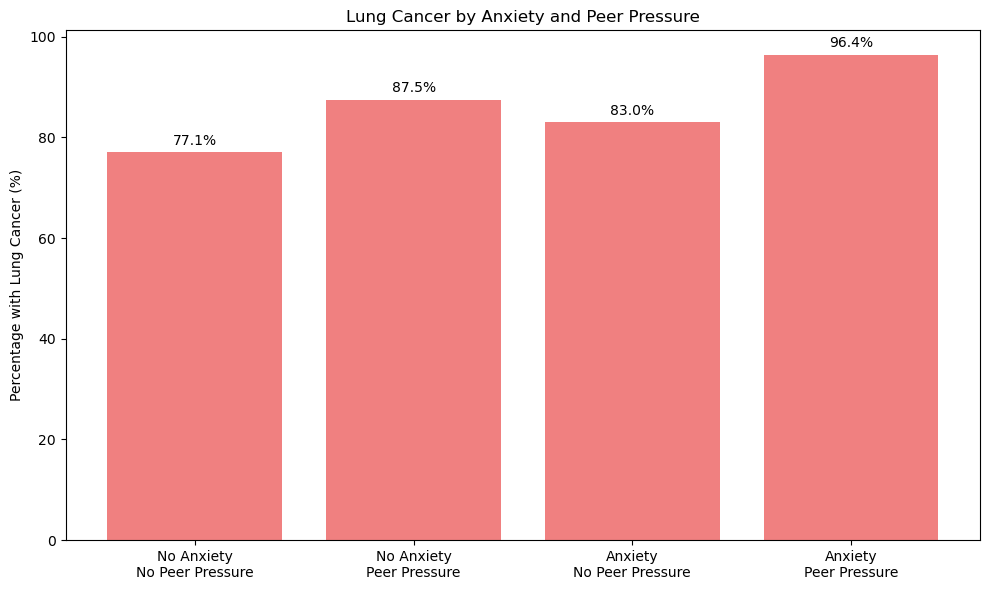

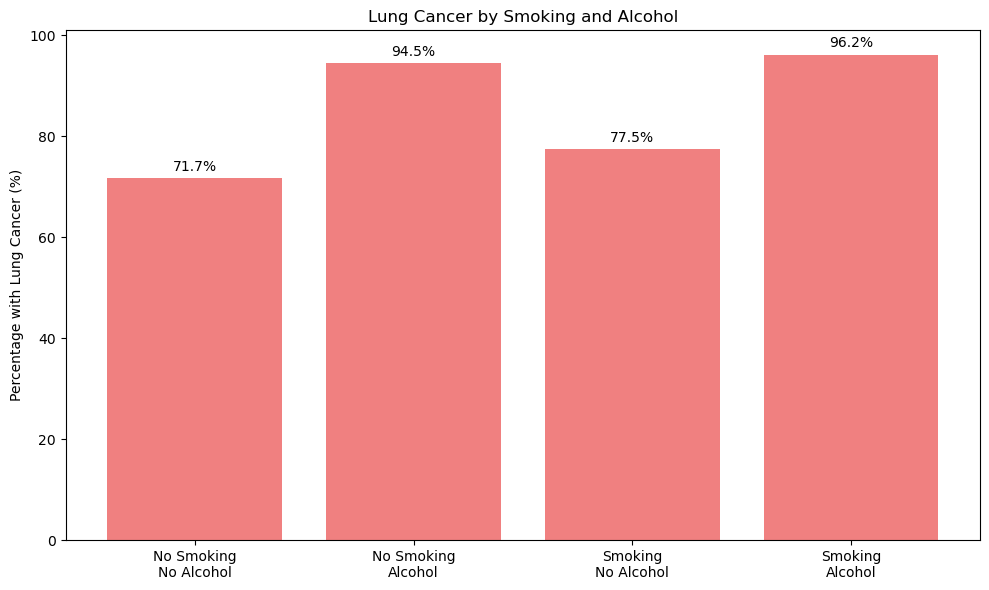

In [3]:
print("\n Cancer Distribution Visualisations")

results = research.lung_cancer_features(data)
data = results[0]
cancer_by_feature = results[1]
psychosocial_dist = results[2]
behavioral_dist = results[3]
print("\n Overall Lung Cancer Distribution")
cancer_dist_fig = research.plot_cancer_distribution(data)
plt.show()

print("\n Cancer Distribution by Individual Factors")
for feature in ['SMOKING', 'ALCOHOL_CONSUMING', 'ANXIETY', 'PEER_PRESSURE']:
    feature_fig = research.plot_cancer_by_feature(data, feature)
    plt.show()

print("\n Cancer Distribution by Combined Factors")
psycho_fig = research.plot_combined_factors(data, psychosocial_dist, 'psychosocial')
plt.show()

behav_fig = research.plot_combined_factors(data, behavioral_dist, 'behavioral')
plt.show()

Inferential Statistics Analysis

Logistic Regression with Interaction terms


 Logistic Regression with Interaction Terms

 Logistic Regression Analysis with Interaction Terms

 Creating Interaction Terms

 Fitting Logistic Regression Models

 Likelihood Ratio Tests
Base vs Psychosocial Interactions: Chi2=13.24, df=4.0, p-value=0.0102
Psychosocial vs Full Model: Chi2=11.05, df=8.0, p-value=0.1991

Selected Model: Model with psychosocial interactions

 Model Summary
Log-Likelihood: -79.17
AIC: 180.35
BIC: 220.17
Pseudo R-squared: 0.2842

 Key Coefficients and Wald Tests
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.2136      0.429      0.498      0.618      -0.627       1.054
AGE_C                     0.0143      0.024      0.602      0.547      -0.032       0.061
GENDER                   -0.5395      0.474     -1.139      0.255      -1.468       0.389
SMOKING                  -0.9047      0.649     -1.

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


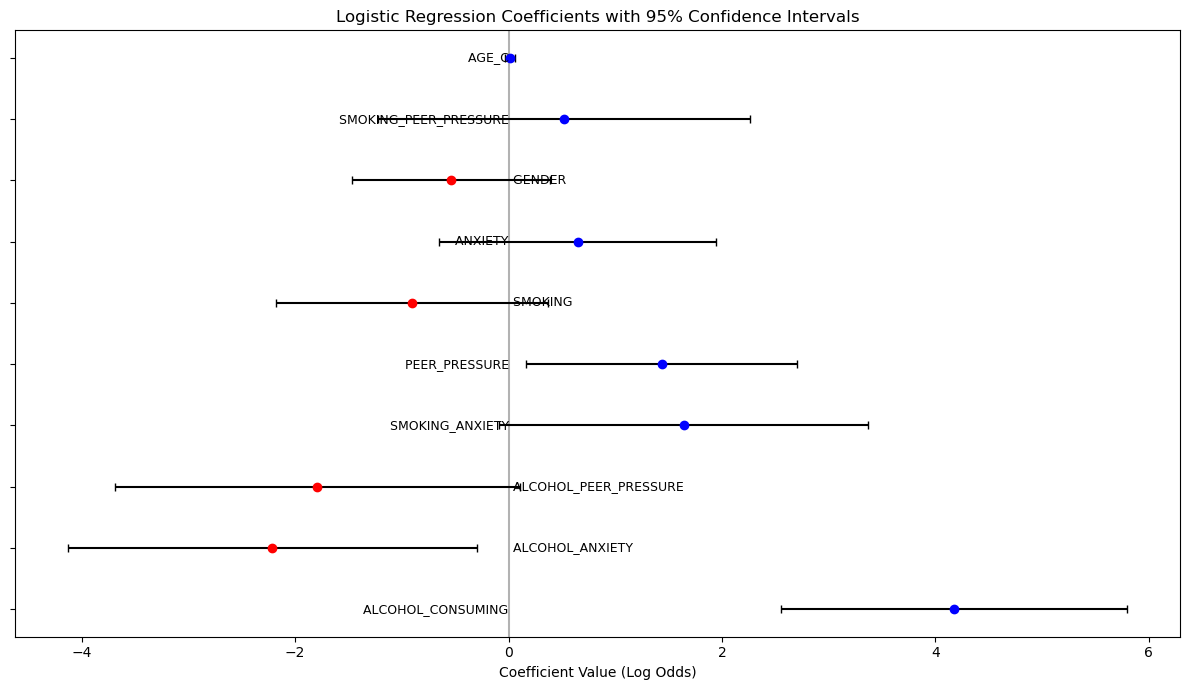


 ROC Curve


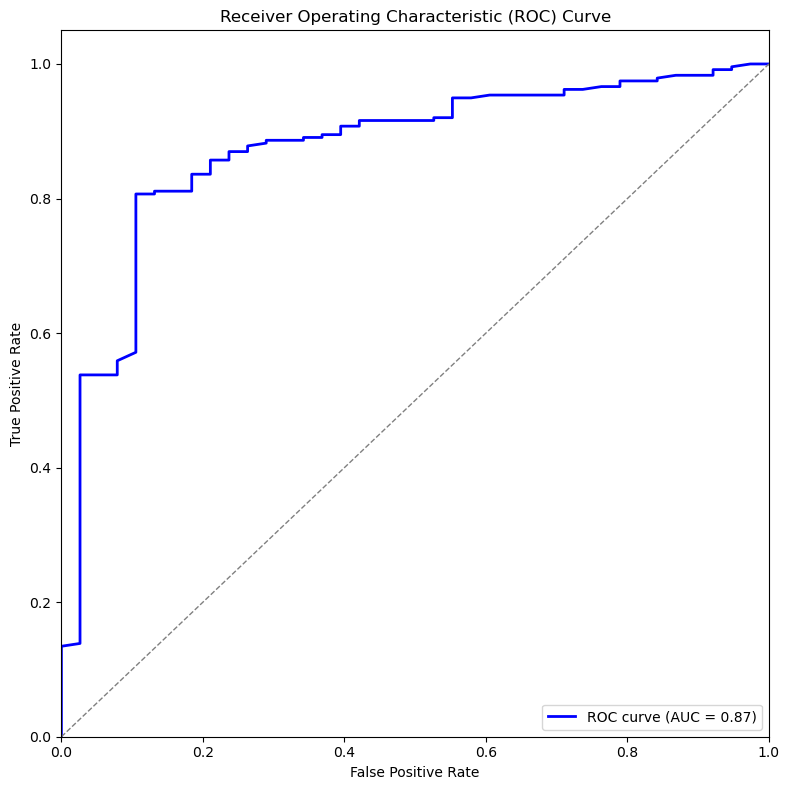


 Confusion Matrix


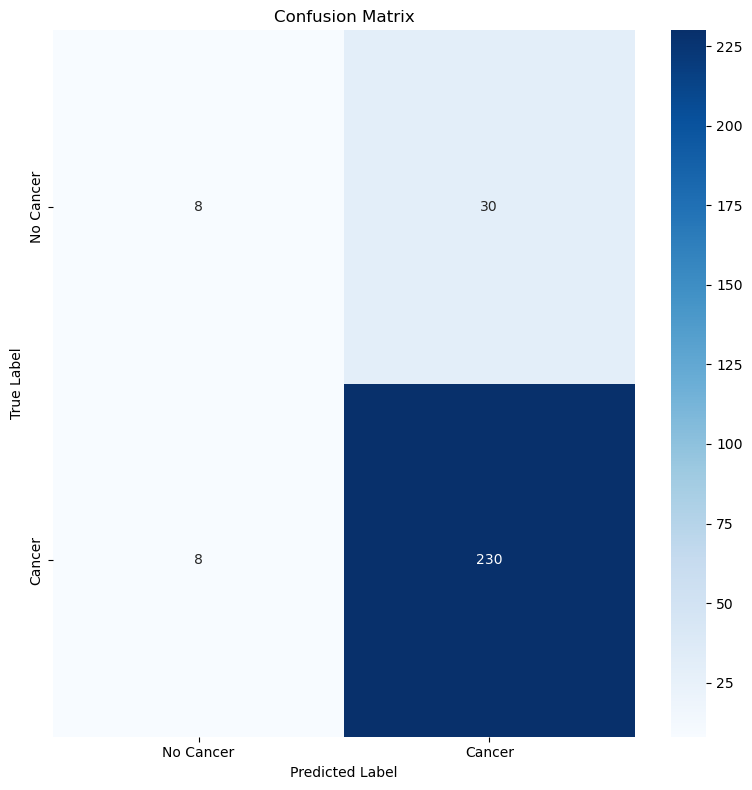


 Interaction Effects


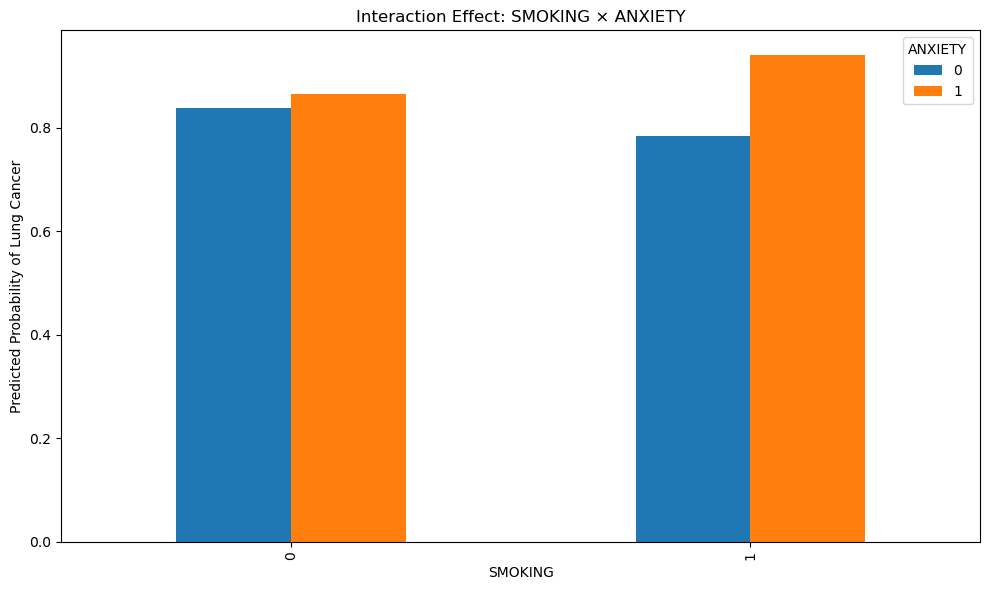


 Significant Interactions
| Variable | Coefficient | Odds Ratio | p-value |
|----------|-------------|------------|---------|
| ALCOHOL_CONSUMING | 4.1713 | 64.7992 | 0.0000 |
| ALCOHOL_ANXIETY | -2.2142 | 0.1092 | 0.0235 |
| PEER_PRESSURE | 1.4326 | 4.1894 | 0.0268 |


In [4]:
print("\n Logistic Regression with Interaction Terms")
from inferential_statistics import inferential_statistics as infer_stats
model, model_data, interaction_results, viz_functions = infer_stats.logistic_regression_analysis(data)

print("\n Coefficient Plot")
coef_fig = viz_functions['coefficients']()
plt.show()

print("\n ROC Curve")
roc_fig = viz_functions['roc_curve']()
plt.show()

print("\n Confusion Matrix")
cm_fig = viz_functions['confusion_matrix']()
plt.show()

print("\n Interaction Effects")
int_fig = viz_functions['interaction_effects']()
plt.show()

print("\n Significant Interactions")
print("| Variable | Coefficient | Odds Ratio | p-value |")
print("|----------|-------------|------------|---------|")
for _, row in interaction_results[interaction_results['p-value'] < 0.05].iterrows():
    print(f"| {row['Variable']} | {row['Coefficient']:.4f} | {row['Odds Ratio']:.4f} | {row['p-value']:.4f} |")

Confidence Interval

In [5]:
print("\n Coefficient Estimates with 95% Confidence Intervals")
ci_table = viz_functions['coefficient_intervals']()

print("\n Main Effects")
print("| Variable | Coefficient | 95% CI | Odds Ratio | OR 95% CI | p-value |")
print("|----------|-------------|--------|------------|-----------|---------|")
for idx, row in ci_table[ci_table['Type'] == 'Main Effect'].iterrows():
    if idx == 'Intercept':
        continue
    print(f"| {idx} | {row['Coefficient']:.4f} | {row['95% CI']} | {row['Odds Ratio']:.4f} | {row['OR 95% CI']} | {row['p-value']:.4f} |")

print("\n Interaction Terms")
print("| Variable | Coefficient | 95% CI | Odds Ratio | OR 95% CI | p-value |")
print("|----------|-------------|--------|------------|-----------|---------|")
for idx, row in ci_table[ci_table['Type'] == 'Interaction'].iterrows():
    if row['p-value'] < 0.05:
        print(f"| **{idx}** | **{row['Coefficient']:.4f}** | **{row['95% CI']}** | **{row['Odds Ratio']:.4f}** | **{row['OR 95% CI']}** | **{row['p-value']:.4f}** |")
    else:
        print(f"| {idx} | {row['Coefficient']:.4f} | {row['95% CI']} | {row['Odds Ratio']:.4f} | {row['OR 95% CI']} | {row['p-value']:.4f} |")


 Coefficient Estimates with 95% Confidence Intervals

 Main Effects
| Variable | Coefficient | 95% CI | Odds Ratio | OR 95% CI | p-value |
|----------|-------------|--------|------------|-----------|---------|
| SMOKING | -0.9047 | (-2.1771, 0.3677) | 0.4047 | (0.1134, 1.4444) | 0.1635 |
| GENDER | -0.5395 | (-1.4682, 0.3892) | 0.5830 | (0.2303, 1.4757) | 0.2549 |
| ANXIETY | 0.6486 | (-0.6493, 1.9465) | 1.9129 | (0.5224, 7.0042) | 0.3273 |
| AGE_C | 0.0143 | (-0.0323, 0.0610) | 1.0144 | (0.9682, 1.0629) | 0.5475 |

 Interaction Terms
| Variable | Coefficient | 95% CI | Odds Ratio | OR 95% CI | p-value |
|----------|-------------|--------|------------|-----------|---------|
| **ALCOHOL_CONSUMING** | **4.1713** | **(2.5477, 5.7949)** | **64.7992** | **(12.7771, 328.6293)** | **0.0000** |
| **ALCOHOL_ANXIETY** | **-2.2142** | **(-4.1307, -0.2977)** | **0.1092** | **(0.0161, 0.7425)** | **0.0235** |
| **PEER_PRESSURE** | **1.4326** | **(0.1647, 2.7004)** | **4.1894** | **(1.1791, 14.8856

Anova test


 Analysis of Variance (ANOVA)

 Analysis of Variance (ANOVA)

 Creating Age Groups

 ANOVA: Lung Cancer by Age Group

Group statistics for AGE_Group:
           count      mean       std
AGE_Group                           
Young          3  0.666667  0.577350
Middle       105  0.828571  0.378691
Older        168  0.886905  0.317656

ANOVA results: F(2, 273) = 1.4140, p = 0.2449

ANOVA is not significant. No post-hoc tests needed.

 Creating Risk Profiles via Clustering


c:\Users\princ\source\repos\school\Research Methods\Assessment\src\inferential_statistics.py:646: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = data.groupby(group_var)[dependent_var].agg(['count', 'mean', 'std'])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



 ANOVA: Lung Cancer by Risk Profile

Group statistics for Risk_Level:
             count      mean       std
Risk_Level                            
High Risk       89  0.966292  0.181499
Low Risk       100  0.710000  0.456048
Medium Risk     87  0.931034  0.254864

ANOVA results: F(2, 273) = 17.3378, p = 0.0000

ANOVA is significant. Performing Tukey's HSD post-hoc test...

Tukey's HSD results:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
High Risk    Low Risk  -0.2563    0.0 -0.3684 -0.1442   True
High Risk Medium Risk  -0.0353 0.7539 -0.1512  0.0807  False
 Low Risk Medium Risk    0.221    0.0  0.1083  0.3338   True
------------------------------------------------------------

Significant pairwise comparisons (p < 0.05):
High Risk vs Low Risk: Mean diff = -0.2563, p = 0.0000
High Risk vs Medium Risk: Mean diff = -0.0353, p = 0.7539
Low Risk vs Med

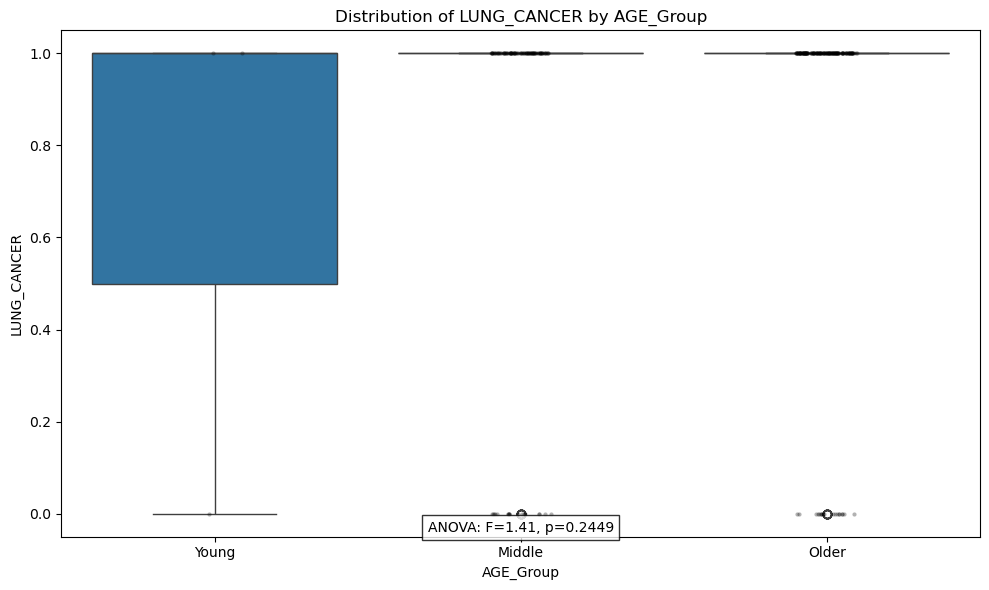

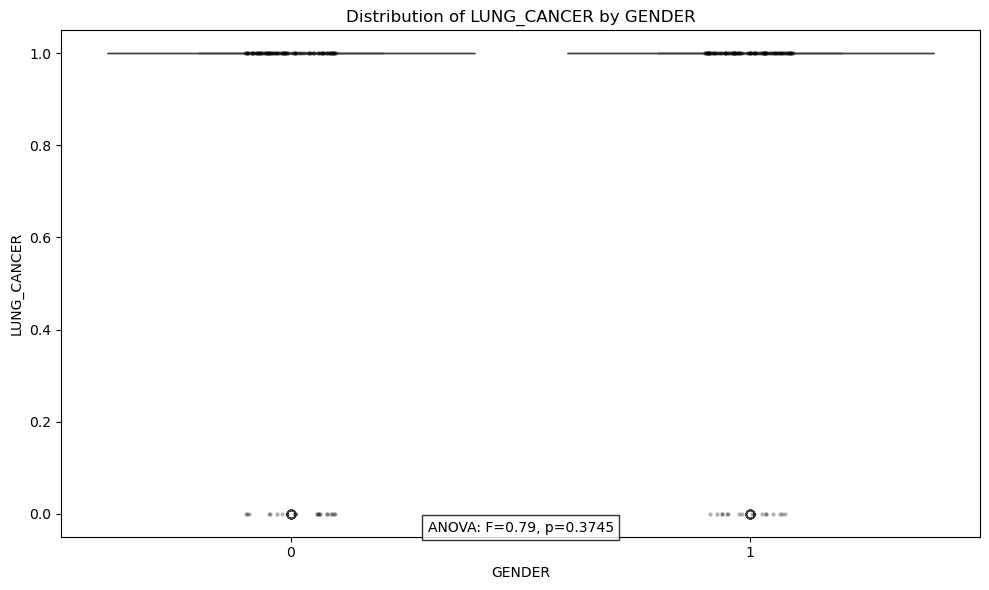

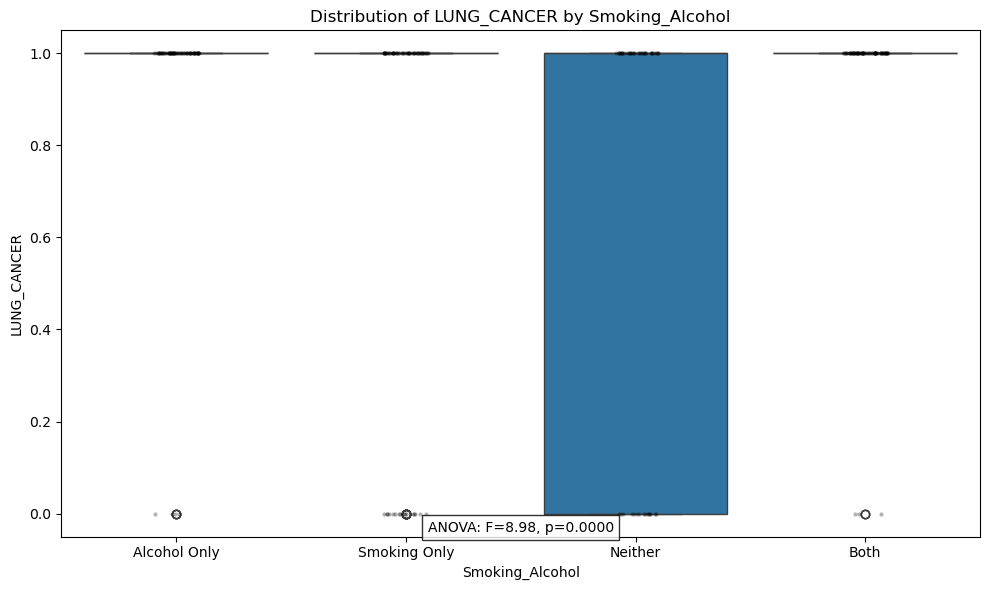


 Mean Comparisons


c:\Users\princ\source\repos\school\Research Methods\Assessment\src\inferential_statistics.py:467: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = anova_data.groupby(actual_group_var)[dependent_var].agg(['mean', 'std', 'count'])


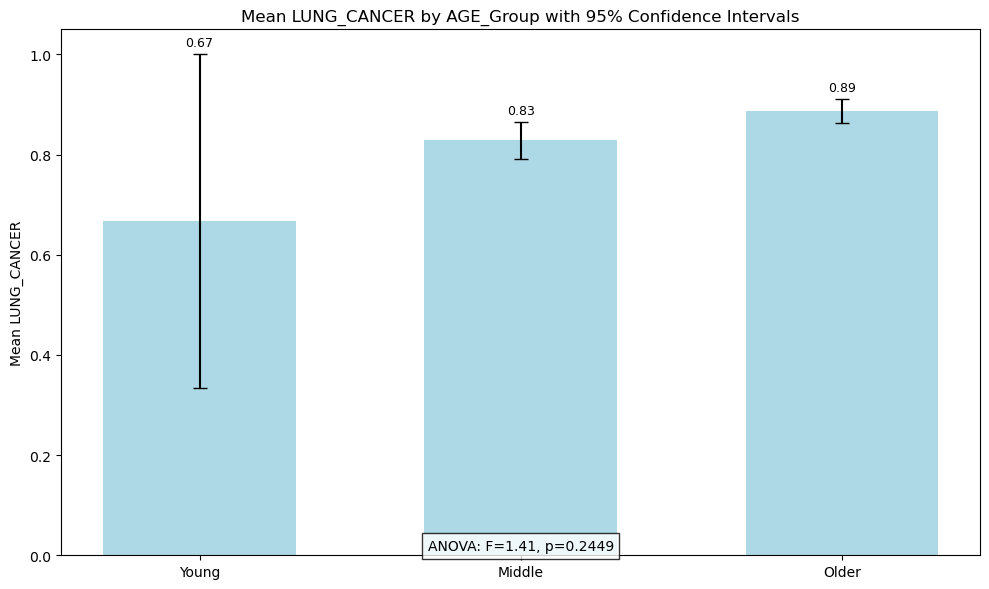

posthoc.data[i]: 1
posthoc.data[i]: 0


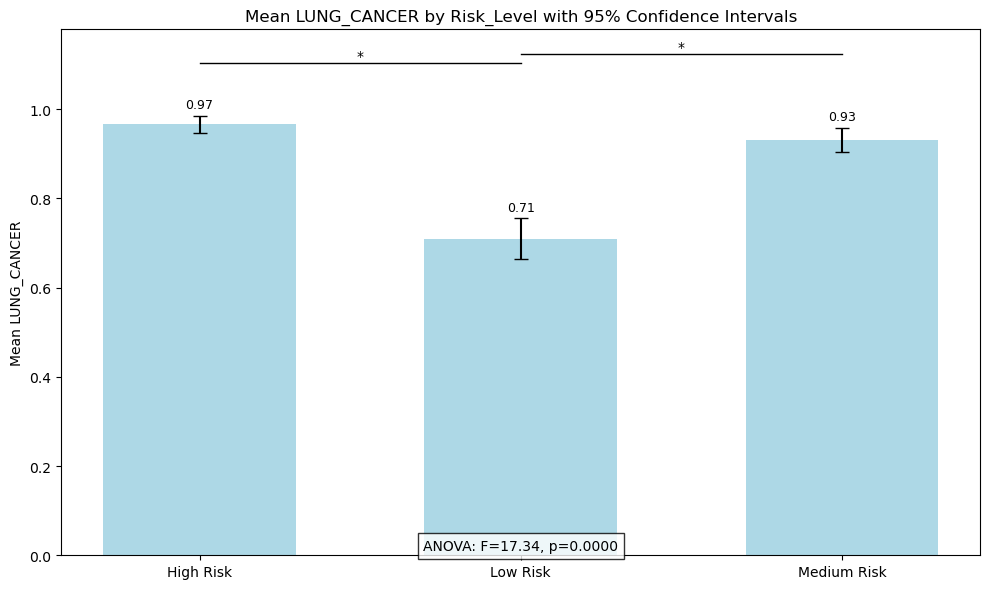


 Post-hoc Test Results


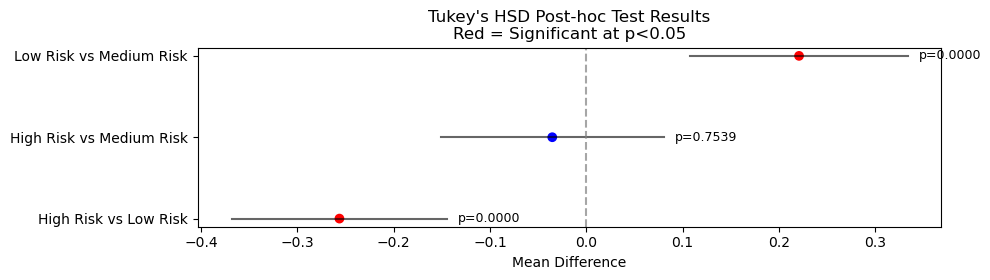


 Risk Profile Characteristics


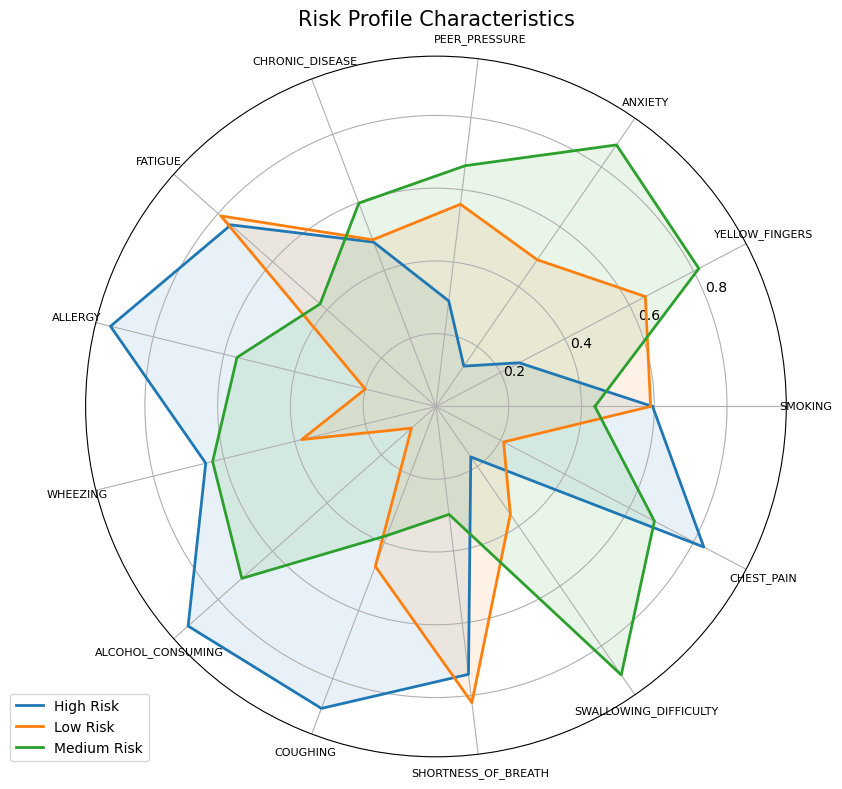


 Significant Group Differences Found
| Grouping Variable | F-value | p-value | Significant Pairwise Comparisons |
|-------------------|---------|---------|----------------------------------|
| Risk_Level | 17.34 | 0.0000 | High Risk vs Low Risk, Low Risk vs Medium Risk |
| Smoking_Alcohol | 8.98 | 0.0000 | Alcohol Only vs Neither, Alcohol Only vs Smoking Only, Both vs Neither, Both vs Smoking Only |


In [6]:
print("\n Analysis of Variance (ANOVA)")
from inferential_statistics import inferential_statistics as infer_stats
anova_results, viz_functions = infer_stats.anova_analysis(data)

print("\n Box Plots by Group")
age_boxplot = viz_functions['group_boxplots']('age_groups')
plt.show()

gender_boxplot = viz_functions['group_boxplots']('gender')
plt.show()

smoking_alcohol_boxplot = viz_functions['group_boxplots']('smoking_alcohol')
plt.show()

print("\n Mean Comparisons")
age_means = viz_functions['group_means']('age_groups')
plt.show()

risk_means = viz_functions['group_means']('risk_profiles')
plt.show()

print("\n Post-hoc Test Results")
posthoc_fig = viz_functions['posthoc_results']('risk_profiles')
plt.show()

if 'risk_profiles' in viz_functions:
    print("\n Risk Profile Characteristics")
    profile_fig = viz_functions['risk_profiles']()
    plt.show()

significant_groups = []
for group_name, results in anova_results.items():
    if results.get('p_value', 1) < 0.05:
        significant_groups.append((group_name, results))


if significant_groups:
    print("\n Significant Group Differences Found")
    print("| Grouping Variable | F-value | p-value | Significant Pairwise Comparisons |")
    print("|-------------------|---------|---------|----------------------------------|")
    
    for group_name, results in significant_groups:
        pairwise_text = "None"
        if 'posthoc_result' in results:
            sig_pairs = []
            posthoc = results['posthoc_result']
            for i in range(len(posthoc.pvalues)):
                if posthoc.pvalues[i] < 0.05:
                    row = posthoc._results_table.data[i+1]
                    group1, group2 = row[0], row[1]
                    sig_pairs.append(f"{group1} vs {group2}")
            
            if sig_pairs:
                pairwise_text = ", ".join(sig_pairs)
            
        print(f"| {results['group_var']} | {results['f_value']:.2f} | {results['p_value']:.4f} | {pairwise_text} |")
else:
    print("\n No Significant Group Differences Found")

Bayesian Analysis

Bayesian Logististic Regression


 Bayesian Logistic Regression Analysis

  Bayesian Logistic Regression Analysis

  Creating Interaction Terms

  Fitting Base Bayesian Model (Main Effects Only)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, AGE_C, GENDER, SMOKING, ALCOHOL_CONSUMING, ANXIETY, PEER_PRESSURE]


Output()

Sampling 4 chains for 5_000 tune and 2_000 draw iterations (20_000 + 8_000 draws total) took 33 seconds.


Output()

...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, AGE_C, GENDER, SMOKING, ALCOHOL_CONSUMING, ANXIETY, PEER_PRESSURE, SMOKING_ANXIETY, SMOKING_PEER_PRESSURE, ALCOHOL_ANXIETY, ALCOHOL_PEER_PRESSURE, AGE_SMOKING, AGE_ALCOHOL, AGE_ANXIETY, AGE_PEER_PRESSURE, GENDER_SMOKING, GENDER_ALCOHOL, GENDER_ANXIETY, GENDER_PEER_PRESSURE]


Output()

Sampling 4 chains for 5_000 tune and 2_000 draw iterations (20_000 + 8_000 draws total) took 51 seconds.


Output()


  Calculating LOO-CV

  LOO Comparison
             rank    elpd_loo     p_loo  elpd_diff        weight         se  \
interaction     0  182.916084  7.032861   0.000000  1.000000e+00  20.329906   
full            1  183.858807  9.680884   0.942722  4.440892e-16  20.380263   
base            2  185.516530  6.206915   2.600446  1.110223e-16  21.030878   

                  dse  warning     scale  
interaction  0.000000    False  deviance  
full         1.910750    False  deviance  
base         1.802184    False  deviance  

Selected model based on LOO: interaction

Selecting final model based on LOO rank 0: interaction

  Model Comparison Summary
Base Model WAIC: -92.73
Interaction Model WAIC: -91.43
Full Model WAIC: -91.83

  LOO Comparison Table:
             rank    elpd_loo     p_loo  elpd_diff        weight         se  \
interaction     0  182.916084  7.032861   0.000000  1.000000e+00  20.329906   
full            1  183.858807  9.680884   0.942722  4.440892e-16  20.380263   
base

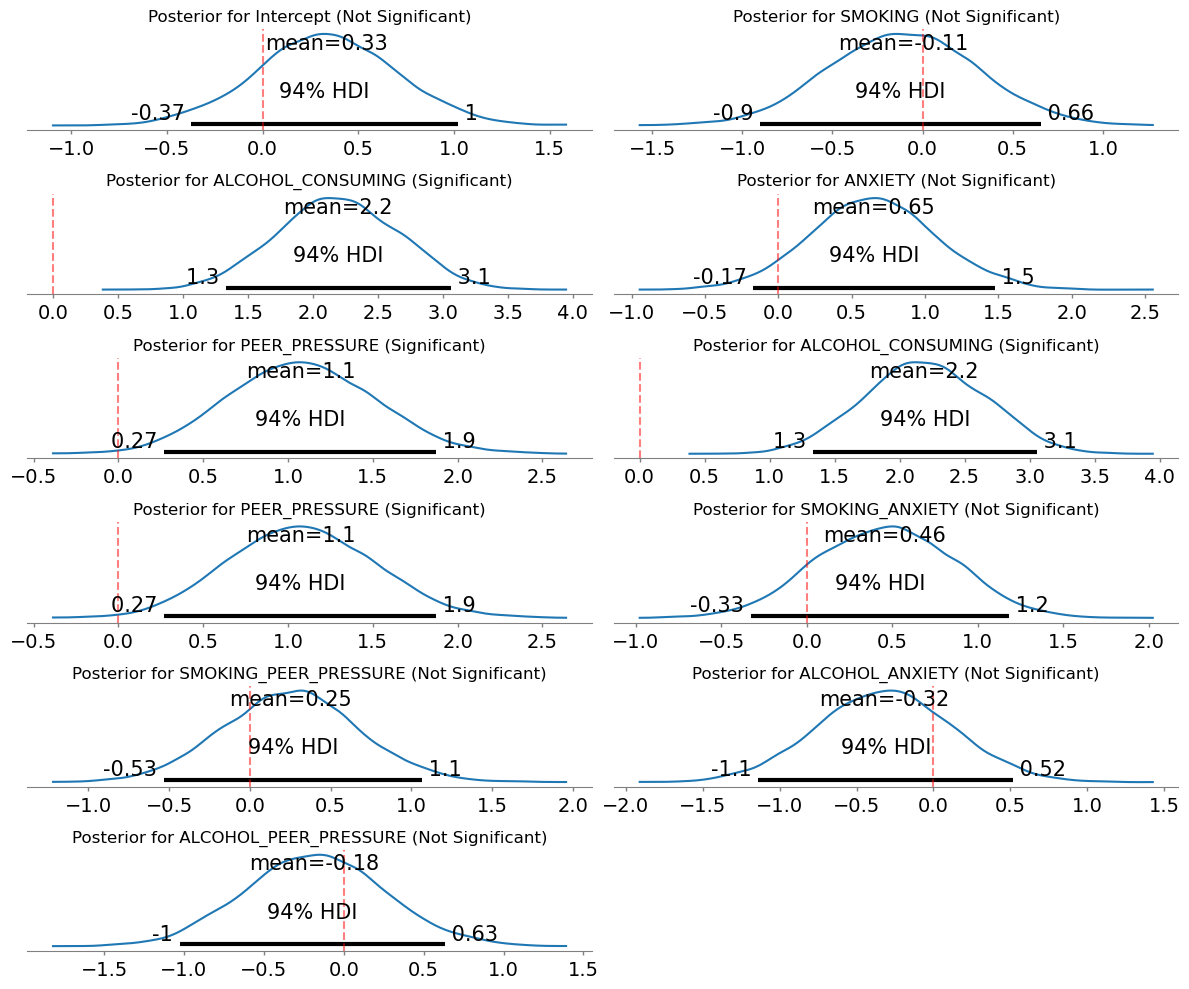


 Coefficient Estimates with 95% Credible Intervals


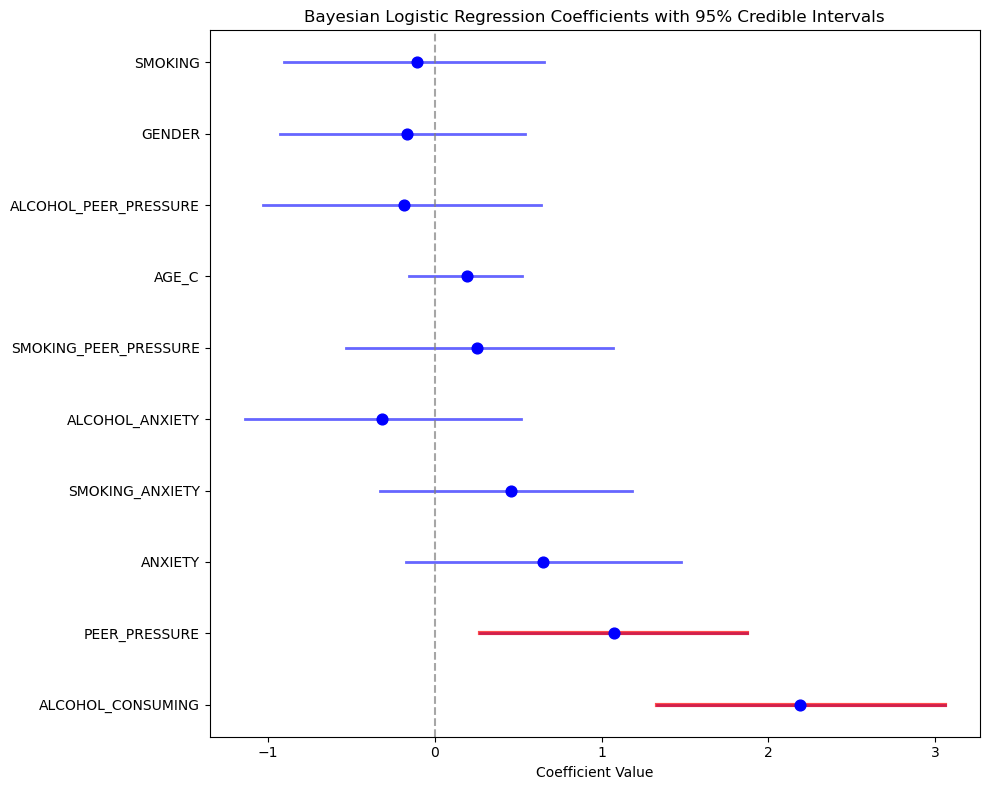


 MCMC Trace Diagnostics


<Figure size 1200x1000 with 0 Axes>

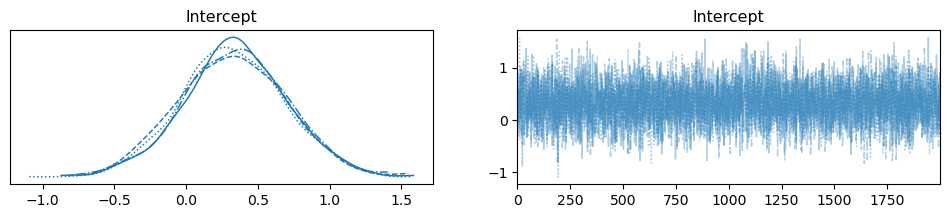

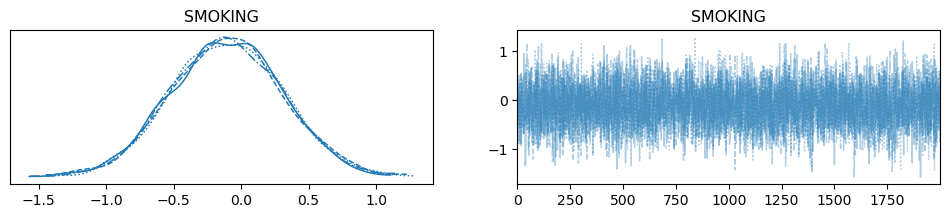

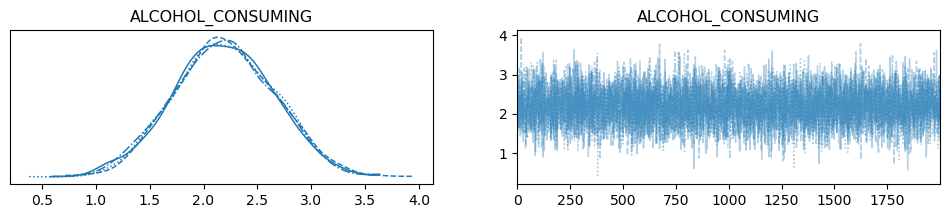

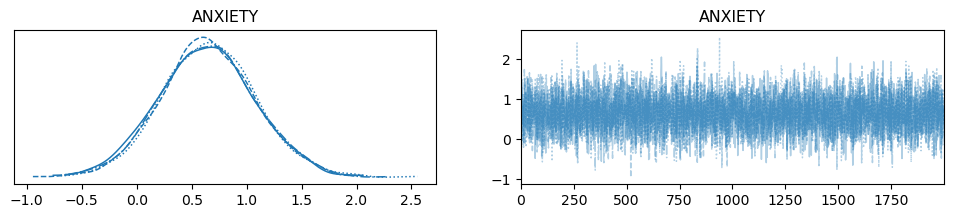

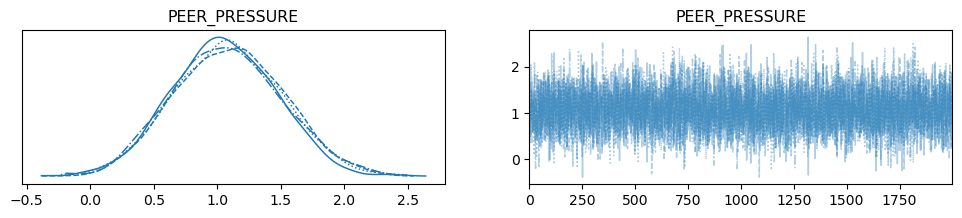

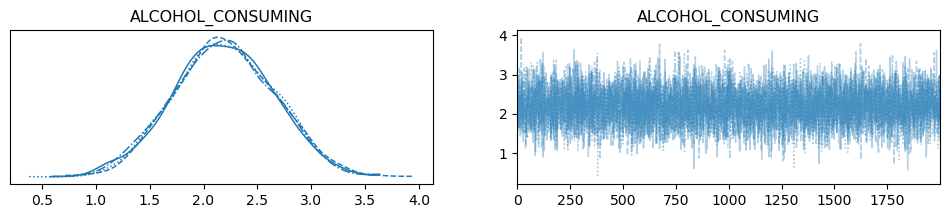

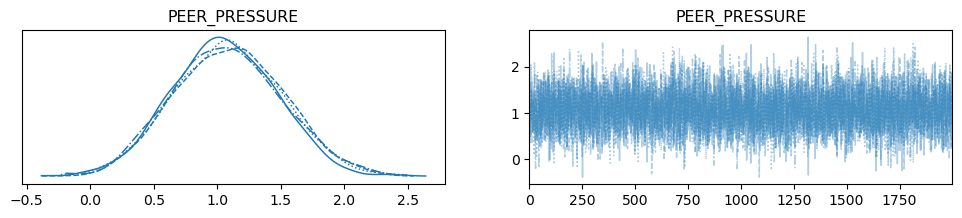

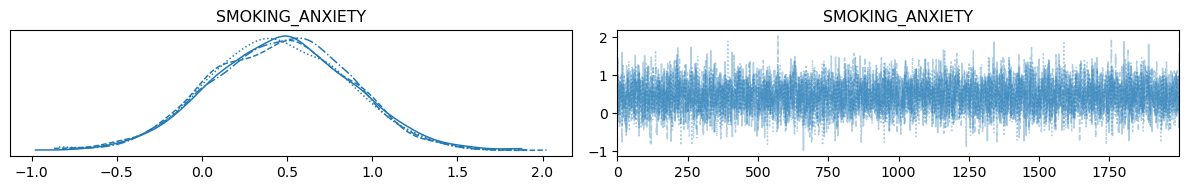


 Model Comparison (WAIC)


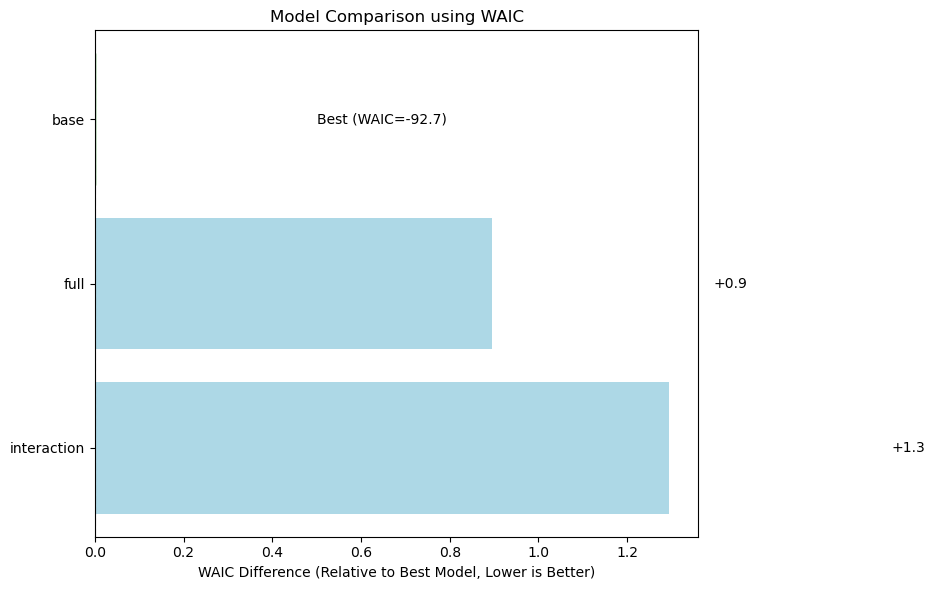


 LOO Model Comparison


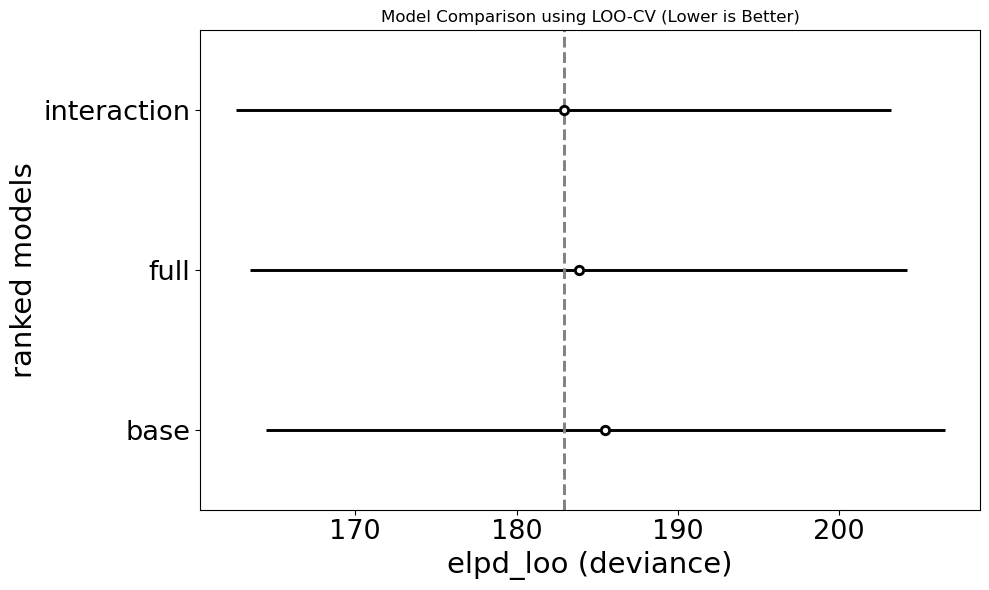


 Interaction Effect Sizes


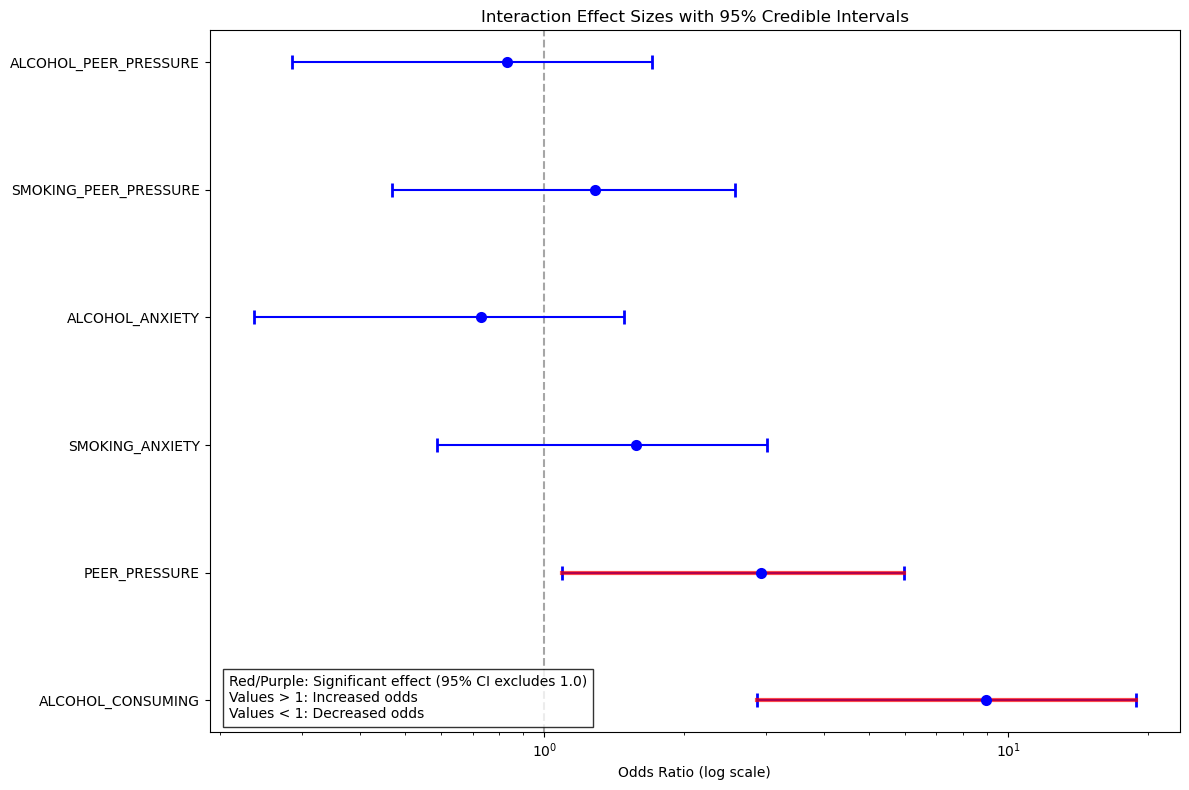


 ROC Curve with Credible Interval


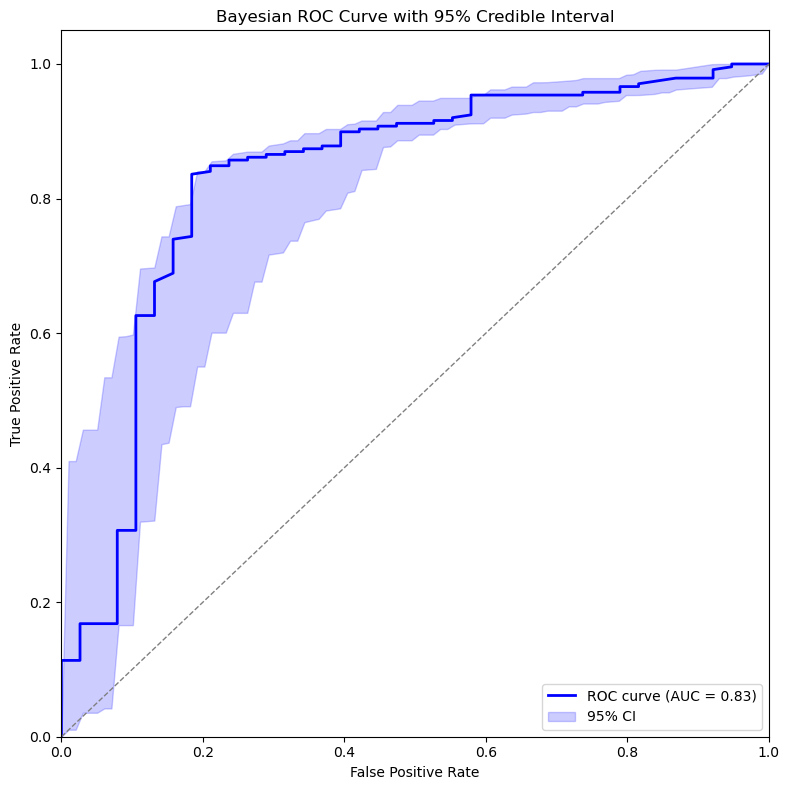


 Confusion Matrix


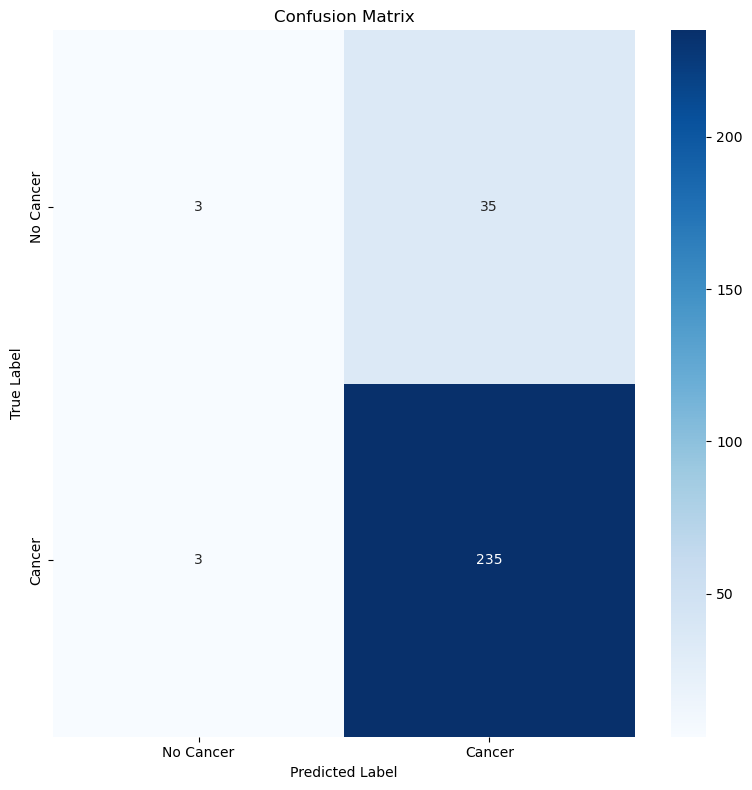


 Parameter Estimates with 95% Credible Intervals

 Main Effects
| Variable | Mean Coefficient | 95% CI | Odds Ratio | OR 95% CI | Significant |
|----------|------------------|--------|------------|-----------|-------------|
| ANXIETY | 0.6461 | (-0.2017, 1.5244) | 2.0977 | (0.8173, 4.5926) | ✗ |
| AGE_C | 0.1927 | (-0.1525, 0.5534) | 1.2327 | (0.8585, 1.7392) | ✗ |
| SMOKING | -0.1072 | (-0.9246, 0.7062) | 0.9789 | (0.3967, 2.0262) | ✗ |
| GENDER | -0.1675 | (-0.9305, 0.6045) | 0.9146 | (0.3944, 1.8304) | ✗ |

 Interaction Terms
| Variable | Mean Coefficient | 95% CI | Odds Ratio | OR 95% CI | Significant |
|----------|------------------|--------|------------|-----------|-------------|
| **ALCOHOL_CONSUMING** | **2.1903** | **(1.2844, 3.0914)** | **9.9687** | **(3.6124, 22.0082)** | **✓** |
| **PEER_PRESSURE** | **1.0778** | **(0.2571, 1.9331)** | **3.2296** | **(1.2932, 6.9107)** | **✓** |
| SMOKING_ANXIETY | 0.4570 | (-0.3304, 1.2426) | 1.7149 | (0.7186, 3.4645) | ✗ |
| SMOKING_PEER

In [7]:
print("\n Bayesian Logistic Regression Analysis")
from bayesian_statistics import bayesian_statistics as bayes_stats

trace, bayes_results, bayes_viz = bayes_stats.bayesian_regression_analysis(data, chains=4, draws=2000, tune=5000, target_accept=0.95)

print("\n Posterior Distributions")
posterior_fig = bayes_viz['posterior_distributions']()
plt.show()

print("\n Coefficient Estimates with 95% Credible Intervals")
coef_fig = bayes_viz['coefficient_intervals']()
plt.show()

print("\n MCMC Trace Diagnostics")
trace_fig = bayes_viz['trace_diagnostics']()
plt.show()

print("\n Model Comparison (WAIC)")
if 'waic_comparison' in bayes_viz:
    waic_fig = bayes_viz['waic_comparison']()
    plt.show()
else:
    print("No WAIC comparison available.")
    
print("\n LOO Model Comparison")
if 'loo_comparison' in bayes_viz:
    loo_fig = bayes_viz['loo_comparison']()
    plt.show()
else:
    print("No LOO comparison available.")

print("\n Interaction Effect Sizes")
interact_fig = bayes_viz['interaction_effects']()
plt.show()

print("\n ROC Curve with Credible Interval")
roc_fig = bayes_viz['roc_curve']()
plt.show()

print("\n Confusion Matrix")
cm_fig = bayes_viz['confusion_matrix']()
plt.show()

print("\n Parameter Estimates with 95% Credible Intervals")
ci_table = bayes_viz['credible_intervals']()

print("\n Main Effects")
print("| Variable | Mean Coefficient | 95% CI | Odds Ratio | OR 95% CI | Significant |")
print("|----------|------------------|--------|------------|-----------|-------------|")
for idx, row in ci_table[ci_table['Type'] == 'Main Effect'].iterrows():
    if idx == 'Intercept':
        continue
    sig_marker = "✓" if row['Significant'] else "✗"
    print(f"| {idx} | {row['Mean']:.4f} | {row['95% CI']} | {row['Odds Ratio']:.4f} | {row['OR 95% CI']} | {sig_marker} |")

print("\n Interaction Terms")
print("| Variable | Mean Coefficient | 95% CI | Odds Ratio | OR 95% CI | Significant |")
print("|----------|------------------|--------|------------|-----------|-------------|")
for idx, row in ci_table[ci_table['Type'] == 'Interaction'].iterrows():
    sig_marker = "✓" if row['Significant'] else "✗"
    if row['Significant']:
        print(f"| **{idx}** | **{row['Mean']:.4f}** | **{row['95% CI']}** | **{row['Odds Ratio']:.4f}** | **{row['OR 95% CI']}** | **{sig_marker}** |")
    else:
        print(f"| {idx} | {row['Mean']:.4f} | {row['95% CI']} | {row['Odds Ratio']:.4f} | {row['OR 95% CI']} | {sig_marker} |")